In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Defining global variables
color_teal = '#008080'  
color_blue = '#4B8BBE'  
color_purple = '#6A5ACD'
color_orange = '#FF8C00'

### First we will get some insight from our customers data

In [3]:
# Load customer data from the database
import sqlite3
conn = sqlite3.connect('fraud_detection.db')
customers_df = pd.read_sql_query("SELECT * FROM customers", conn)
customers_df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,pop_group,location
0,115-04-4507,4218196001337,Kathy,Johnson,F,863 Lawrence Valleys,Staten Island,NY,10302,40.630600,-74.137901,468730,Accounting technician,1982-10-03,888022315787,adults_2550,urban
1,715-55-5575,4351161559407816183,Elaine,Fuller,F,310 Kendra Common Apt. 164,Peabody,MA,1960,42.532600,-70.961197,50944,Professor Emeritus,1994-06-07,917558277935,adults_2550,urban
2,167-48-5821,4192832764832,Melinda,Cameron,F,05641 Robin Port,Waukomis,OK,73773,36.278099,-97.899597,1744,International aid/development worker,1934-05-30,718172762479,adults_50up,rural
3,406-83-7518,4238849696532874,Brandon,Williams,M,26916 Carlson Mountain,Los Angeles,CA,90019,34.048199,-118.334297,2383912,Seismic interpreter,1991-12-26,947268892251,adults_2550,urban
4,697-93-1877,4514627048281480,Lisa,Hernandez,F,809 Burns Creek,Austin,TX,78727,30.425400,-97.719498,940359,Medical laboratory scientific officer,1998-05-22,888335239225,adults_2550,urban


In [4]:
# Customer demographics analysis - Using an stacked bar plot
print("Customers - Preliminary Demographics Analysis:\n")

# Population group distribution
pop_group_dist = customers_df['pop_group'].value_counts()
print(f"\nPopulation Group Distribution:")
for pop_group, count in pop_group_dist.items():
    print(f"  {pop_group}: {count} ({count/len(customers_df)*100:.1f}%)")

location_dist = customers_df['location'].value_counts()
print(f"\nLocation Distribution:")
for location, count in location_dist.items():
    print(f"  {location}: {count} ({count/len(customers_df)*100:.1f}%)")

gender_dist = customers_df['gender'].value_counts()
print(f"\nGender Distribution:")
for gender, count in gender_dist.items():
    print(f"  {gender}: {count} ({count/len(customers_df)*100:.1f}%)")



Customers - Preliminary Demographics Analysis:


Population Group Distribution:
  adults_50up: 516 (51.1%)
  adults_2550: 401 (39.7%)
  young_adults: 93 (9.2%)

Location Distribution:
  urban: 969 (95.9%)
  rural: 41 (4.1%)

Gender Distribution:
  M: 531 (52.6%)
  F: 479 (47.4%)


In [5]:
# Plotting Groups/Locations
# Create cross-tabulation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
# https://www.geeksforgeeks.org/python/pandas-crosstab-function-in-python/

customers_cross_loc = pd.crosstab(customers_df['pop_group'], customers_df['location'])
customers_cross_loc

location,rural,urban
pop_group,,
adults_2550,18,383
adults_50up,17,499
young_adults,6,87


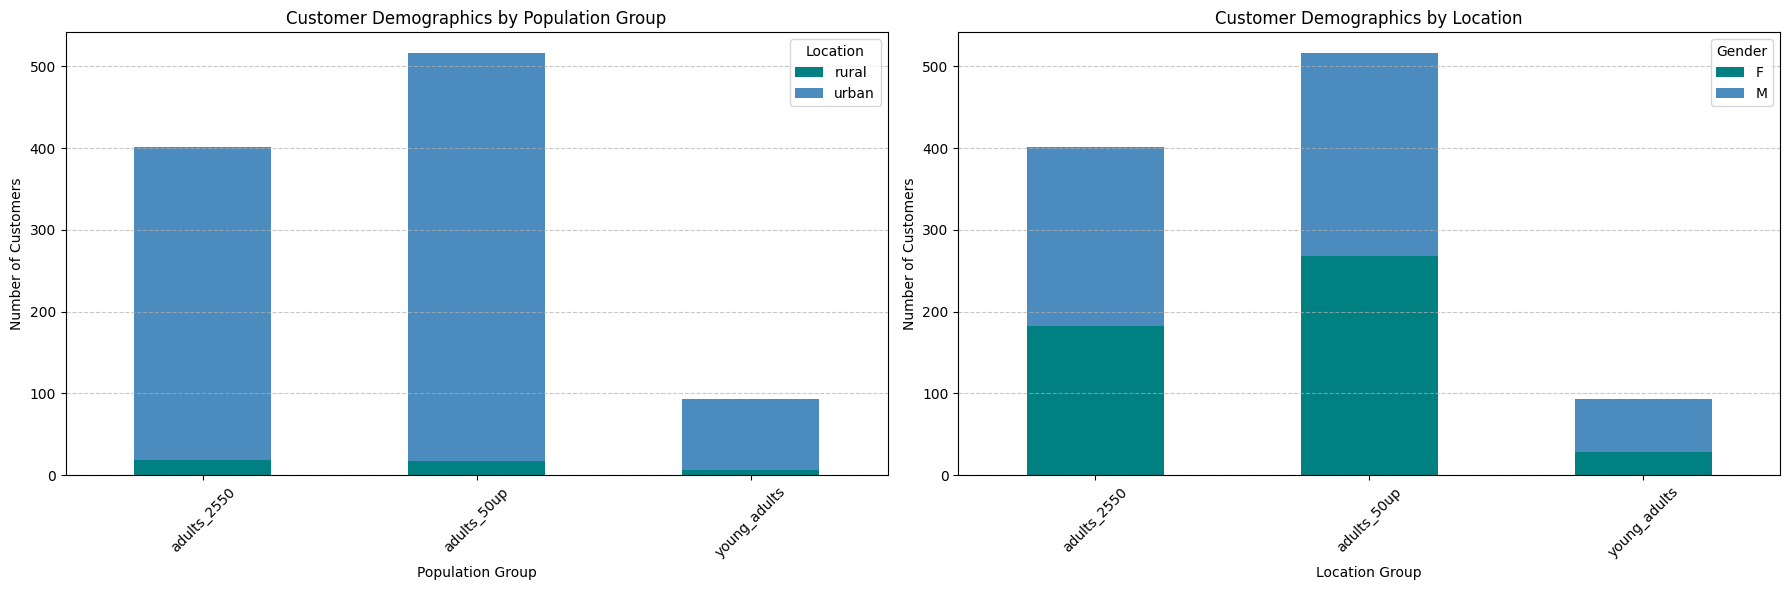

In [6]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
customers_cross_loc.plot(kind='bar', stacked=True, color=[color_teal, color_blue], ax=axes[0])
axes[0].set_title('Customer Demographics by Population Group')
axes[0].set_xlabel('Population Group')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Location')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plotting
customers_cross_gender = pd.crosstab(customers_df['pop_group'], customers_df['gender'])
customers_cross_gender.plot(kind='bar', stacked=True, color=[color_teal, color_blue], ax=axes[1])

axes[1].set_title('Customer Demographics by Location')
axes[1].set_xlabel('Location Group')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Gender')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Top 10 States by Customer Count:
  GA: 29 customers
  IL: 30 customers
  OH: 31 customers
  NC: 34 customers
  MI: 39 customers
  PA: 47 customers
  FL: 48 customers
  NY: 63 customers
  TX: 80 customers
  CA: 132 customers


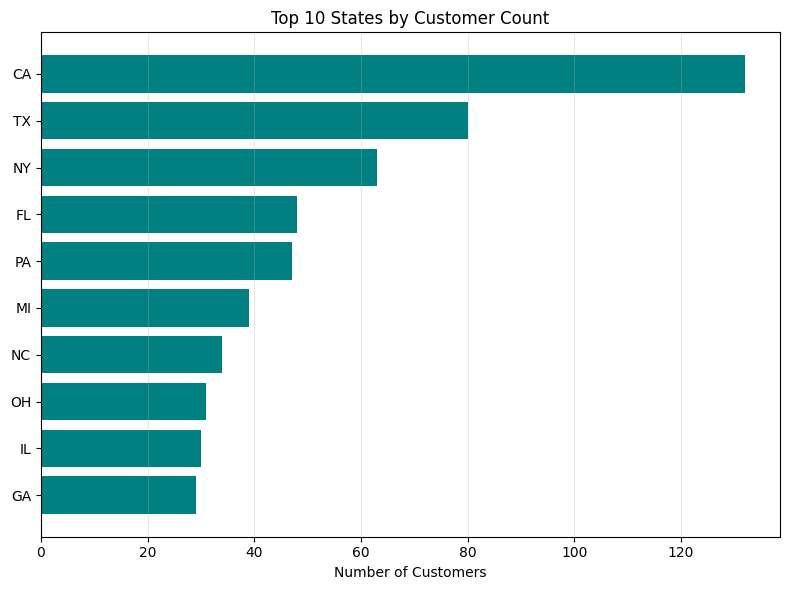

In [7]:
# Top 10 States
num_states_viz = 10
state_counts = customers_df['state'].value_counts().head(num_states_viz).sort_values(ascending=True)

print(f"\nTop {num_states_viz} States by Customer Count:")
for state, count in state_counts.items():
    print(f"  {state}: {count} customers")
    
plt.figure(figsize=(8, 6))
# Convert to list to avoid array type issues( Pylance )
plt.barh(range(len(state_counts)), list(state_counts.values), color=color_teal)
plt.yticks(range(len(state_counts)), list(state_counts.index))
plt.xlabel('Number of Customers')
plt.title(f'Top {num_states_viz} States by Customer Count')
plt.grid(True, alpha=0.3, axis='x')
#plt.gca().invert_yaxis()  # Put highest at top
plt.tight_layout()
plt.show()

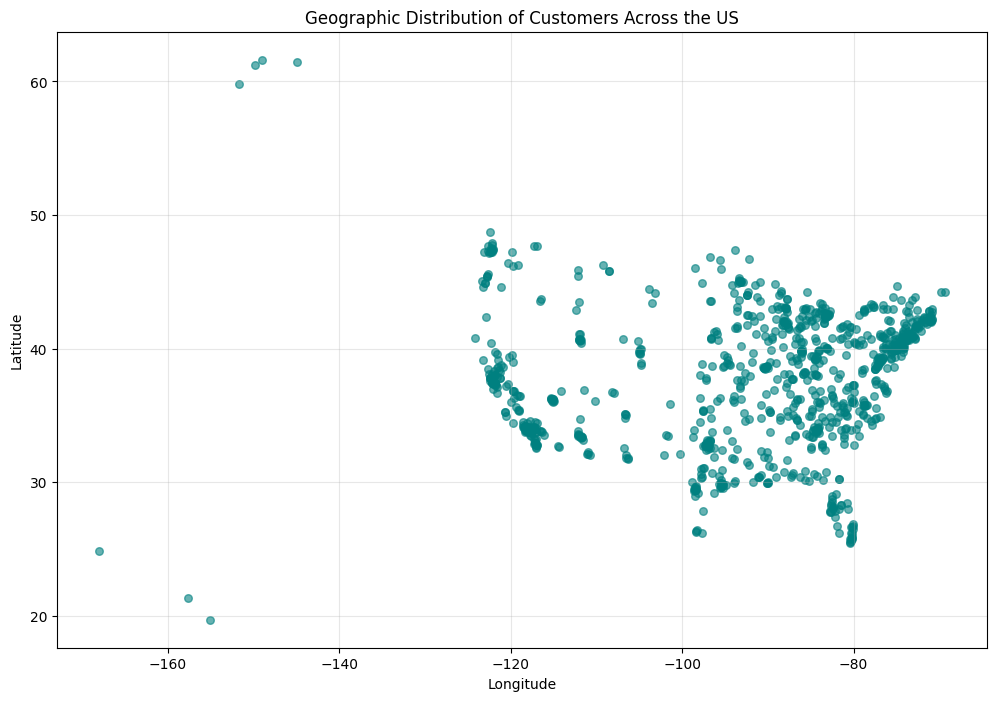

In [8]:
# Geographic distribution - Using a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(customers_df['long'], customers_df['lat'], 
           c=color_teal,  alpha=0.6, s=30)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Customers Across the US')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# US State abbreviation to full name mapping
us_states = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

# Add full state names - Feature Engineering
customers_df['state_full'] = customers_df['state'].map(us_states)

# Check for any unmapped states
unmapped = customers_df[customers_df['state_full'].isna()]['state'].unique()
if len(unmapped) > 0:
    print(f"Unmapped state codes: {unmapped}")

In [10]:
# https://plotly.com/python-api-reference/generated/plotly.express.scatter_map.html#plotly.express.scatter_map
# https://www.datacamp.com/tutorial/making-map-in-python-using-plotly-library-guide
import plotly.express as px

# Create a full name column
# We can show the name on hover. The dataset is synthetic, so there are no privacy concerns.
customers_df['full_name'] = customers_df['first'] + ' ' + customers_df['last'] # Feature Engineering

# Create scatter mapbox
fig = px.scatter_map(
    customers_df,
    lat='lat',
    lon='long',
    color='state',
    hover_name='full_name',
    hover_data=['city', 'state_full', 'city_pop', 'job'],  #customdata
    zoom=3,
    height=600,
    title='Customer Geographic Distribution',
    map_style='open-street-map'
)

fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>" + # Name
                  "State: %{customdata[1]}<br>" +
                  "City: %{customdata[0]}<br>" +
                  "Population: %{customdata[2]:,}<br>" +
                  "Job: %{customdata[3]}<br>" +
                  "<extra></extra>"  # This removes lat and long from hover
)

fig.update_layout(
    mapbox=dict(
        center=dict(lat=39.8283, lon=-98.5795),
        zoom=3
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    title_font_size=16,
    title_x=0.5,  # Center title
    showlegend=True,
    legend=dict(orientation="v", x=1.02, y=1)
)
fig.show()

### Transaction analysis

In [11]:
# Load transaction data using SQL JOIN between customers and transactions tables
# This JOIN retrieves only the data needed for visualizations
joined_query = """
SELECT 
    t.trans_num,
    t.trans_date,
    t.trans_time,
    t.category,
    t.amt,
    t.is_fraud,
    t.merchant,
    t.merch_lat,
    t.merch_long,
    c.ssn,
    c.gender,
    c.state,
    c.city,
    c.pop_group,
    c.location,
    c.job,
    c.lat as customer_lat,
    c.long as customer_long
FROM transactions t
INNER JOIN customers c ON t.ssn = c.ssn
"""

transactions_df = pd.read_sql_query(joined_query, conn)
print(f"Loaded {len(transactions_df):,} transactions with customer data via SQL JOIN")

Loaded 4,740,009 transactions with customer data via SQL JOIN


In [12]:
# Transaction analysis 

# Transaction categories
total_transactions = len(transactions_df)
if 'category' in transactions_df.columns:
    category_dist = transactions_df['category'].value_counts()
    print(f"\nTransaction Categories (from transactions file):")
    for category, count in category_dist.items():
        print(f"  {category}: {count} ({count/total_transactions*100:.1f}%)")

# Amount statistics
if 'amt' in transactions_df.columns:
    print(f"\nTransaction Amount Statistics:")
    print(f"  Mean: ${transactions_df['amt'].mean():.2f}")
    print(f"  Median: ${transactions_df['amt'].median():.2f}")
    print(f"  Min: ${transactions_df['amt'].min():.2f}")
    print(f"  Max: ${transactions_df['amt'].max():.2f}")
    print(f"  Std Dev: ${transactions_df['amt'].std():.2f}")

# Fraud statistics
if 'is_fraud' in transactions_df.columns:
    fraud_dist = transactions_df['is_fraud'].value_counts()
    fraud_rate = fraud_dist.get(1, 0) / total_transactions * 100
    print(f"\nFraud Statistics (from sample):")
    print(f"  Legitimate Transactions: {fraud_dist.get(0, 0)}")
    print(f"  Fraudulent Transactions: {fraud_dist.get(1, 0)}")
    print(f"  Fraud Rate: {fraud_rate:.2f}%")


Transaction Categories (from transactions file):
  shopping_pos: 465205 (9.8%)
  home: 446403 (9.4%)
  grocery_pos: 444495 (9.4%)
  gas_transport: 415826 (8.8%)
  kids_pets: 412790 (8.7%)
  food_dining: 359691 (7.6%)
  entertainment: 347621 (7.3%)
  shopping_net: 339902 (7.2%)
  personal_care: 333618 (7.0%)
  misc_pos: 314311 (6.6%)
  health_fitness: 295404 (6.2%)
  misc_net: 213809 (4.5%)
  grocery_net: 197116 (4.2%)
  travel: 153818 (3.2%)

Transaction Amount Statistics:
  Mean: $68.61
  Median: $44.28
  Min: $1.00
  Max: $51019.93
  Std Dev: $160.53

Fraud Statistics (from sample):
  Legitimate Transactions: 4730471
  Fraudulent Transactions: 9538
  Fraud Rate: 0.20%


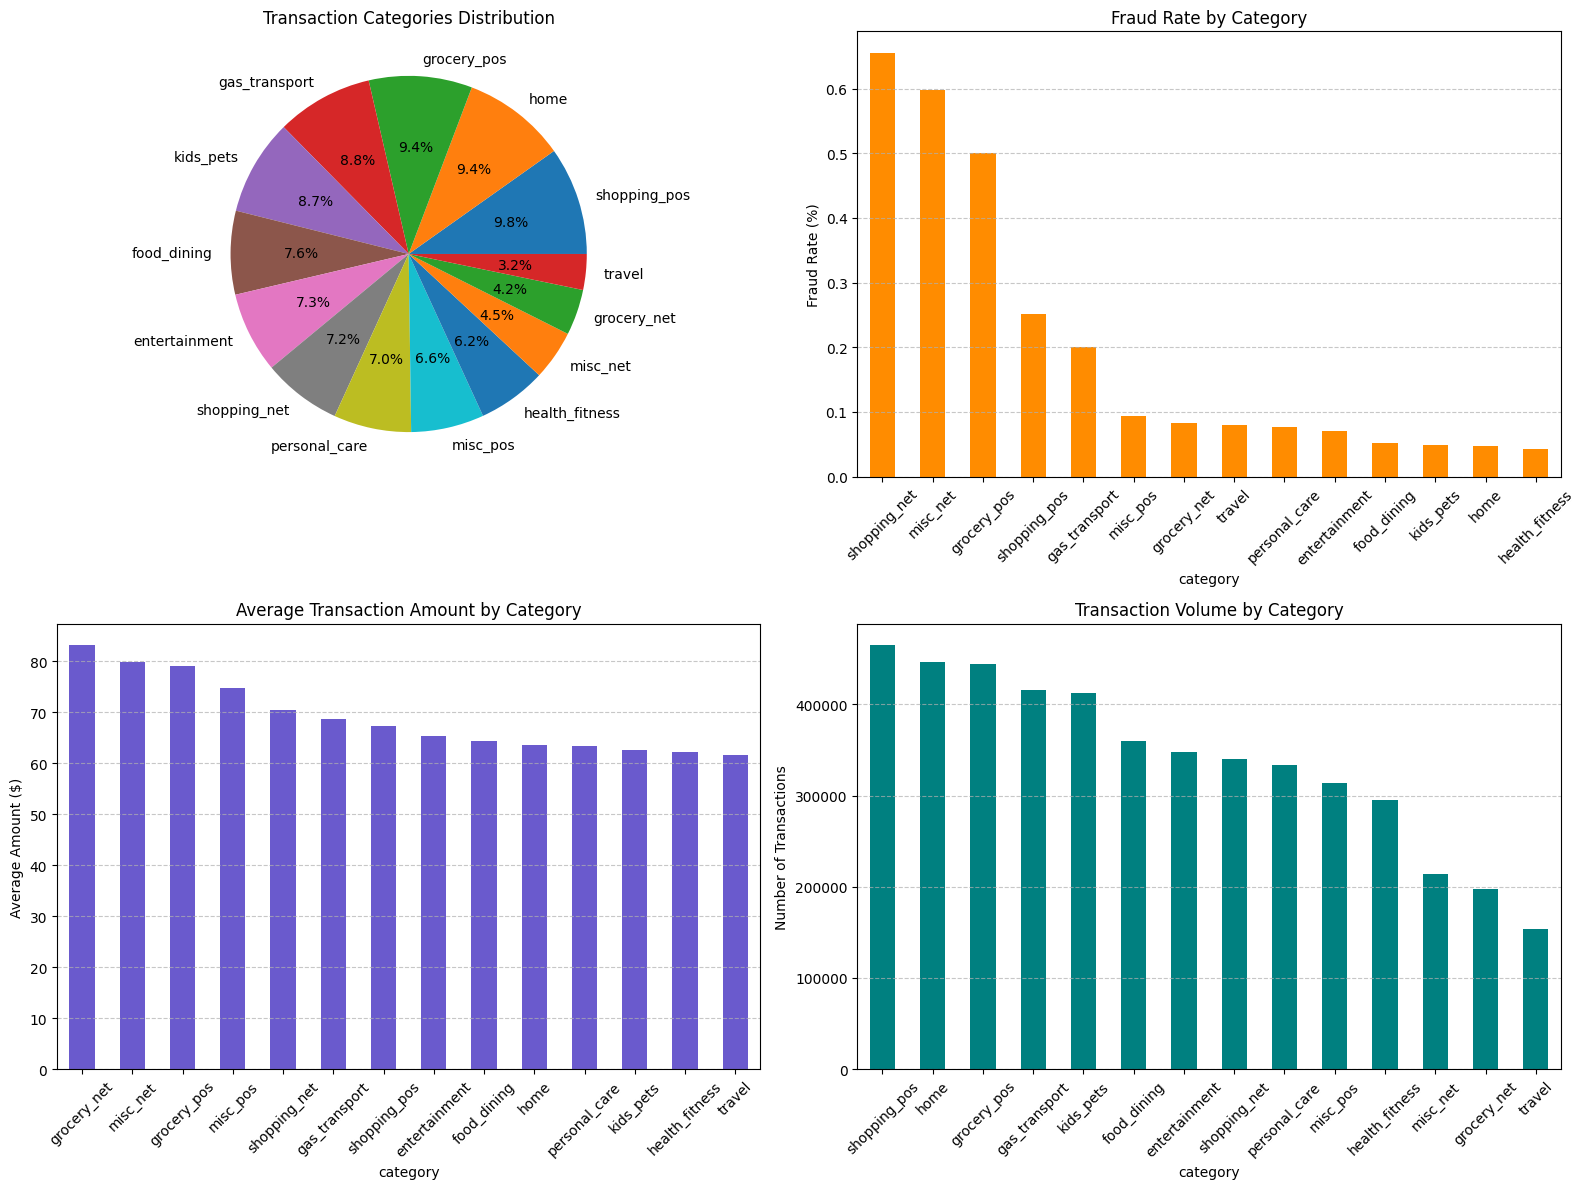

In [13]:
# Category distribution 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Category distribution
axes[0,0].pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%')
axes[0,0].set_title('Transaction Categories Distribution')

# Fraud rate by category
fraud_by_category = transactions_df.groupby('category')['is_fraud'].mean() * 100
fraud_by_category = fraud_by_category.sort_values(ascending=False) # Sort by fraud rate
fraud_by_category.plot(kind='bar', ax=axes[0,1], color=color_orange)
axes[0,1].set_title('Fraud Rate by Category')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', linestyle='--', alpha=0.7)

# Average amount by category
avg_amount_by_category = transactions_df.groupby('category')['amt'].mean()
avg_amount_by_category = avg_amount_by_category.sort_values(ascending=False) # Sort by amount
avg_amount_by_category.plot(kind='bar', ax=axes[1,0], color=color_purple)
axes[1,0].set_title('Average Transaction Amount by Category')
axes[1,0].set_ylabel('Average Amount ($)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)

# Transaction volume by category
category_dist = category_dist.sort_values(ascending=False) # Sort by volume
category_dist.plot(kind='bar', ax=axes[1,1], color=color_teal)
axes[1,1].set_title('Transaction Volume by Category')
axes[1,1].set_ylabel('Number of Transactions')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
# Feature Engineering: Create time-based features for analysis

transactions_df['trans_date'] = pd.to_datetime(transactions_df['trans_date'])
transactions_df['hour'] = pd.to_datetime(transactions_df['trans_time'], format='%H:%M:%S').dt.hour
transactions_df['day_of_week'] = transactions_df['trans_date'].dt.day_name()

# Additional feature: Calculate distance between customer and merchant
import useful_functions as uf
# Create distance feature
transactions_df['distance_km'] = uf.calculate_distance(
    transactions_df['customer_lat'], transactions_df['customer_long'],
    transactions_df['merch_lat'], transactions_df['merch_long']
)

#print(f"Added feature engineering: hour, day_of_week, and distance_km columns")
#print(f"Average distance between customer and merchant: {transactions_df['distance_km'].mean():.2f} km")


Distance Analysis:
Average distance for legitimate transactions: 76.32 km
Average distance for fraudulent transactions: 76.63 km


C:\Users\labreu\AppData\Local\Temp\ipykernel_6696\4293878894.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



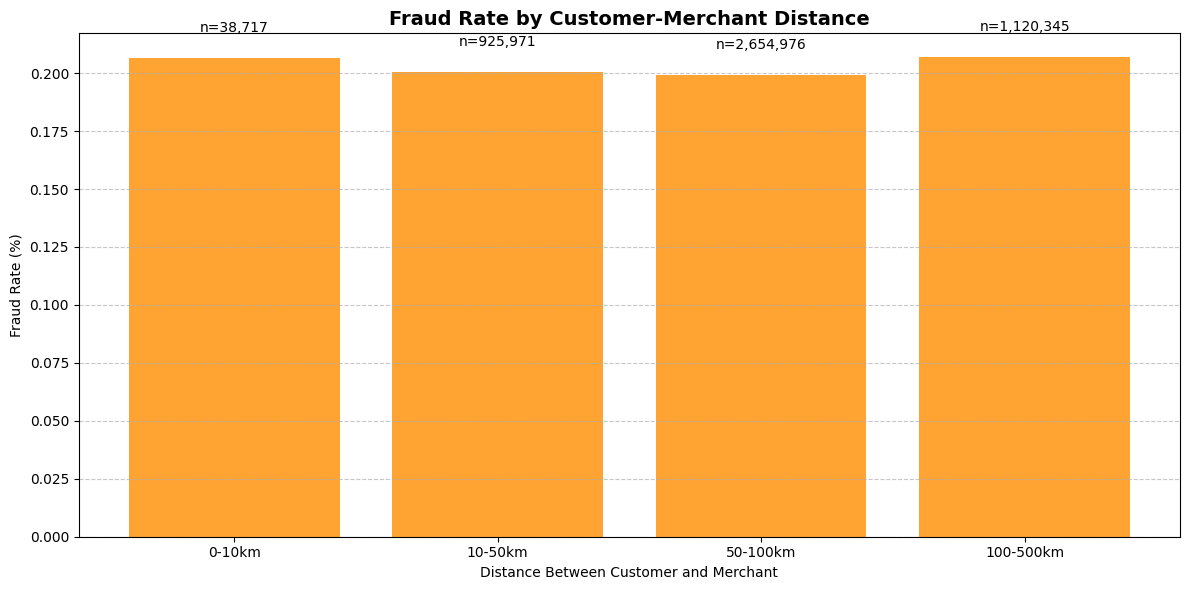


Fraud Rate by Distance Category:
  0-10km: 0.207% (38,717 transactions)
  10-50km: 0.200% (925,971 transactions)
  50-100km: 0.199% (2,654,976 transactions)
  100-500km: 0.207% (1,120,345 transactions)
  500km+: nan% (0 transactions)


In [15]:
# Simple distance vs fraud analysis 
print(f"\nDistance Analysis:")
print(f"Average distance for legitimate transactions: {transactions_df[transactions_df['is_fraud'] == 0]['distance_km'].mean():.2f} km")
print(f"Average distance for fraudulent transactions: {transactions_df[transactions_df['is_fraud'] == 1]['distance_km'].mean():.2f} km")

# Create simple distance bins and show fraud rate
plt.figure(figsize=(12, 6))

# Create meaningful distance categories
transactions_df['distance_category'] = pd.cut(transactions_df['distance_km'], 
                                            bins=[0, 10, 50, 100, 500, float('inf')], 
                                            labels=['0-10km', '10-50km', '50-100km', '100-500km', '500km+'])

# Calculate fraud rate by distance category
fraud_by_distance_cat = transactions_df.groupby('distance_category')['is_fraud'].agg(['mean', 'count']).reset_index()
fraud_by_distance_cat['fraud_rate_pct'] = fraud_by_distance_cat['mean'] * 100

# Plot fraud rate by distance category
plt.bar(fraud_by_distance_cat['distance_category'], fraud_by_distance_cat['fraud_rate_pct'], 
        color=color_orange, alpha=0.8)
plt.title('Fraud Rate by Customer-Merchant Distance', fontsize=14, fontweight='bold')
plt.xlabel('Distance Between Customer and Merchant')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on bars
for i, (cat, rate, count) in enumerate(zip(fraud_by_distance_cat['distance_category'], 
                                          fraud_by_distance_cat['fraud_rate_pct'],
                                          fraud_by_distance_cat['count'])):
    plt.text(i, rate + 0.01, f'n={count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print the summary
print(f"\nFraud Rate by Distance Category:")
for _, row in fraud_by_distance_cat.iterrows():
    print(f"  {row['distance_category']}: {row['fraud_rate_pct']:.3f}% ({row['count']:,} transactions)")

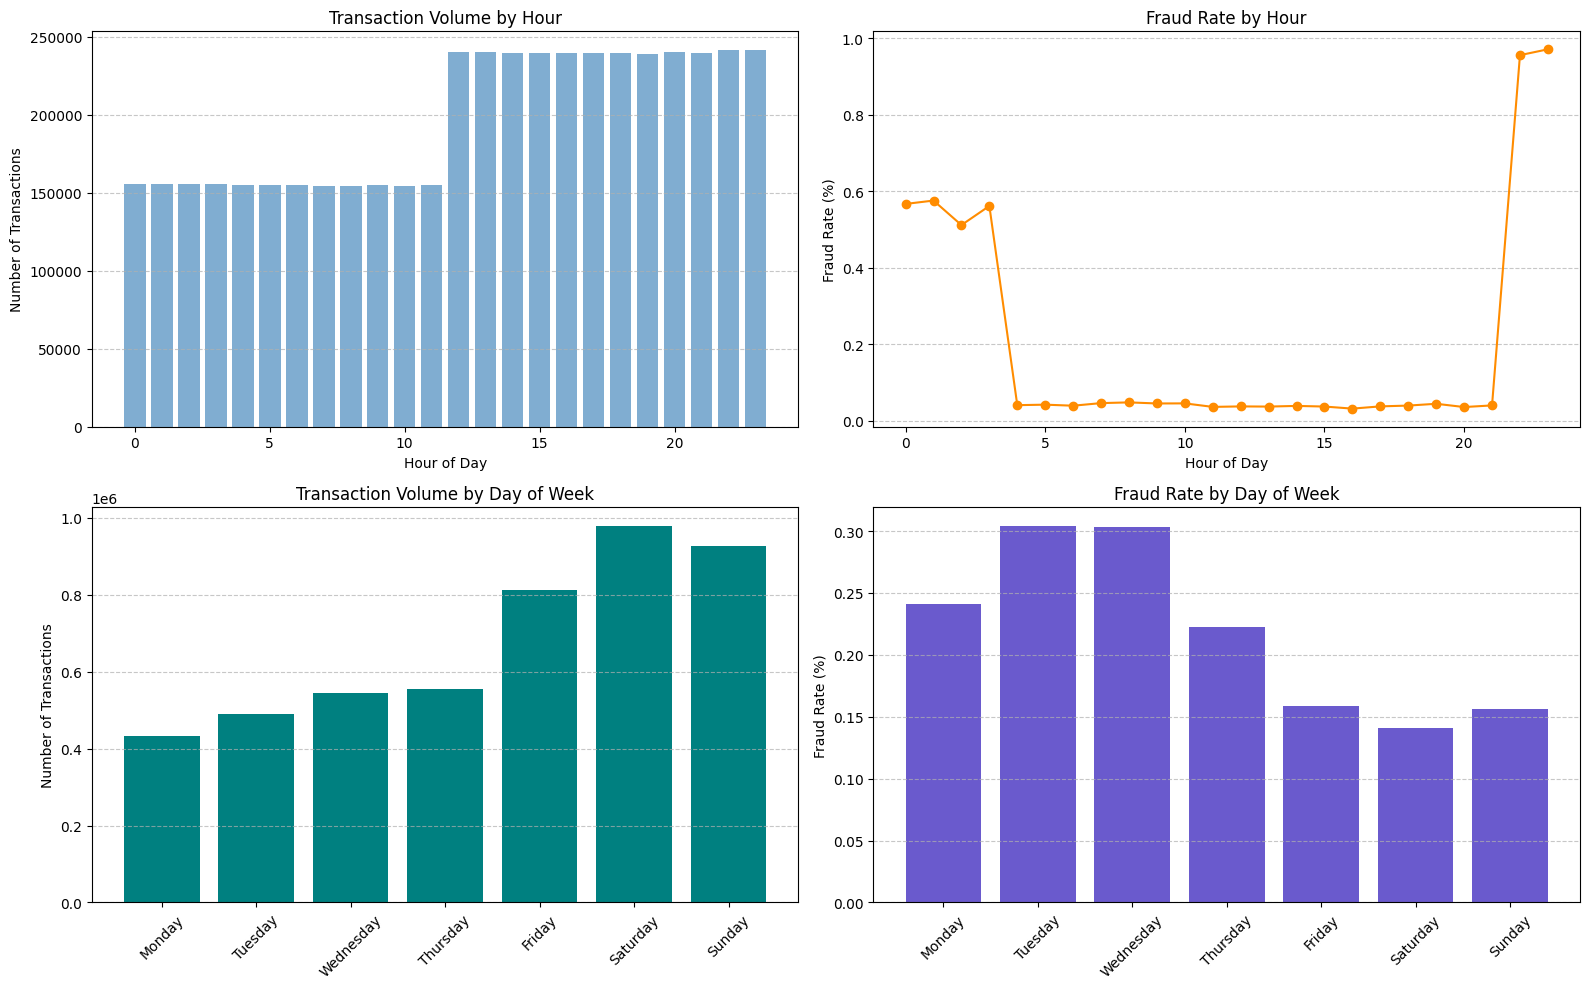

In [16]:
# Time-based patterns analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly transaction patterns
hourly_transactions = transactions_df.groupby('hour').size()
hourly_fraud = transactions_df.groupby('hour')['is_fraud'].mean() * 100

axes[0,0].bar(hourly_transactions.index, hourly_transactions.values, color=color_blue, alpha=0.7)
axes[0,0].set_title('Transaction Volume by Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Number of Transactions')
axes[0,0].grid(axis='y', linestyle='--', alpha=0.7)

axes[0,1].plot(hourly_fraud.index, hourly_fraud.values, marker='o', color=color_orange)
axes[0,1].set_title('Fraud Rate by Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].grid(axis='y', linestyle='--', alpha=0.7)

# Day of week patterns
daily_transactions = transactions_df.groupby('day_of_week').size()
daily_fraud = transactions_df.groupby('day_of_week')['is_fraud'].mean() * 100

# Reorder days properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_transactions = daily_transactions.reindex(day_order)
daily_fraud = daily_fraud.reindex(day_order)

axes[1,0].bar(daily_transactions.index, daily_transactions.values, color=color_teal)
axes[1,0].set_title('Transaction Volume by Day of Week')
axes[1,0].set_ylabel('Number of Transactions')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1,1].bar(daily_fraud.index, daily_fraud.values, color=color_purple)
axes[1,1].set_title('Fraud Rate by Day of Week')
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [17]:
# Gathering fraud and legitimate transaction amounts
fraud_data = transactions_df[transactions_df['is_fraud'] == 1]['amt']
legit_data = transactions_df[transactions_df['is_fraud'] == 0]['amt']

# Trying to find a reasonable upper limit for visualization
print(f"50th percentile (median): ${transactions_df['amt'].quantile(0.50):.2f}")
print(f"75th percentile (Q3): ${transactions_df['amt'].quantile(0.75):.2f}")
print(f"90th percentile: ${transactions_df['amt'].quantile(0.90):.2f}")
print(f"95th percentile: ${transactions_df['amt'].quantile(0.95):.2f}")
print(f"99th percentile: ${transactions_df['amt'].quantile(0.99):.2f}")
print(f"Max: ${transactions_df['amt'].max():.2f}")

50th percentile (median): $44.28
75th percentile (Q3): $81.16
90th percentile: $141.02
95th percentile: $202.70
99th percentile: $510.90
Max: $51019.93


In [18]:
# Limit to reasonable range for better visualization
upper_limit = 500


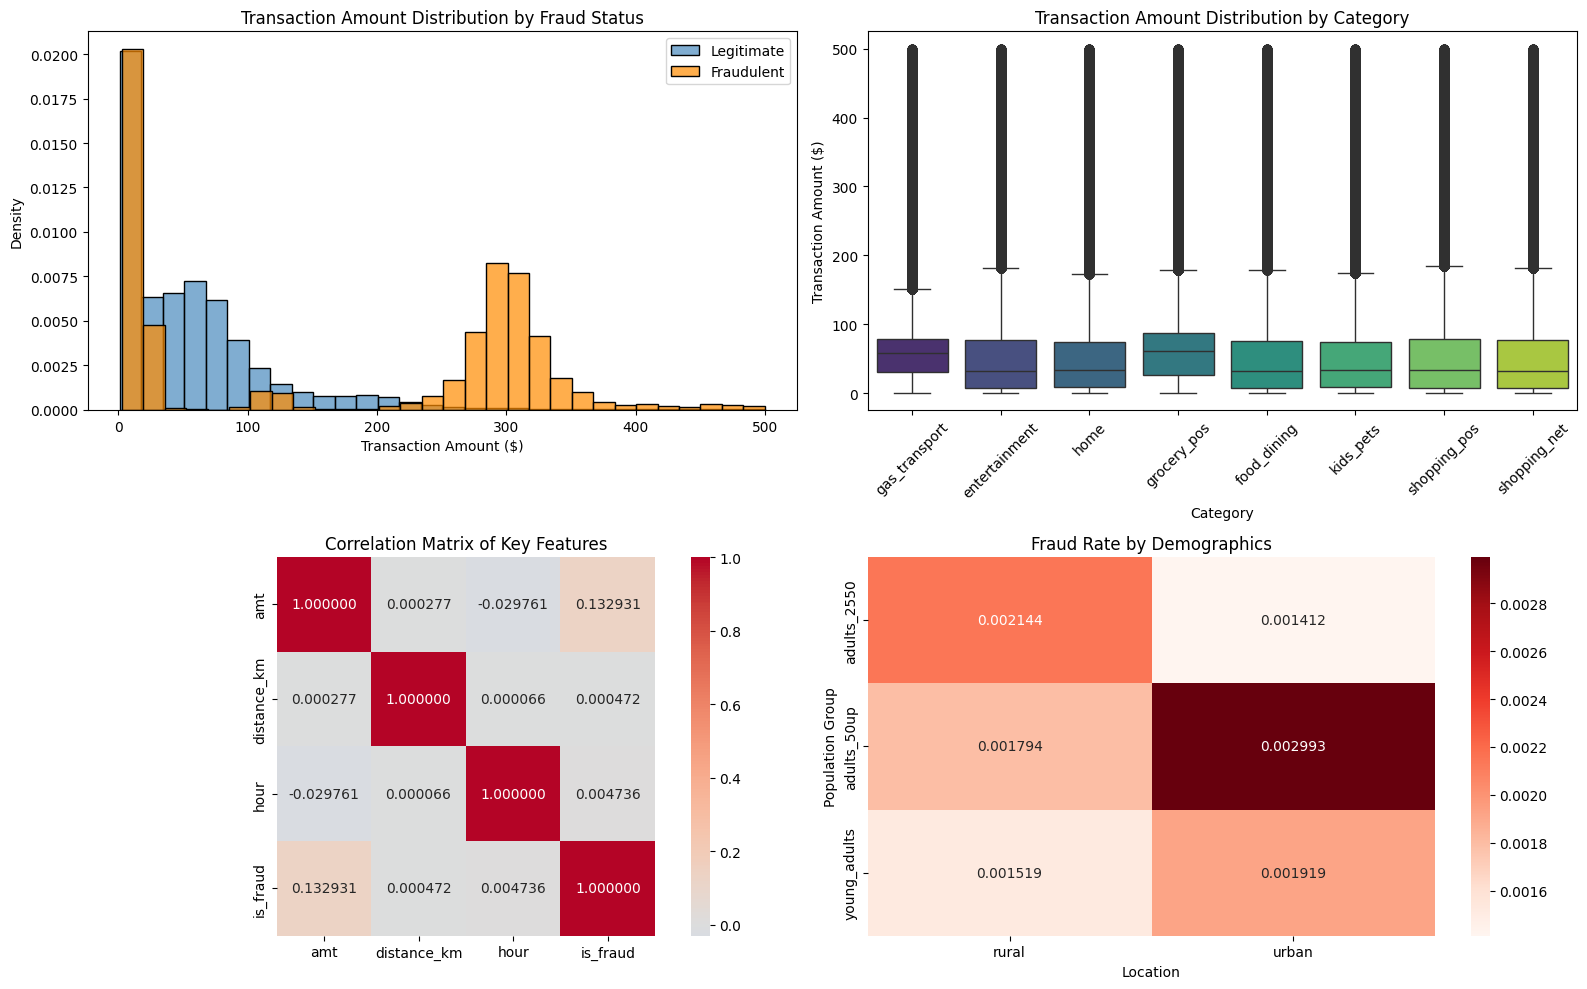

In [19]:
# Enhanced visualizations using seaborn for better statistical plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Transaction amount distribution by fraud status using seaborn
fraud_data_limited = fraud_data[fraud_data <= upper_limit]
legit_data_limited = legit_data[legit_data <= upper_limit]

sns.histplot(legit_data_limited, bins=30, alpha=0.7, color=color_blue, 
             label='Legitimate', ax=axes[0,0], stat='density')
sns.histplot(fraud_data_limited, bins=30, alpha=0.7, color=color_orange, 
             label='Fraudulent', ax=axes[0,0], stat='density')
axes[0,0].set_title('Transaction Amount Distribution by Fraud Status')
axes[0,0].set_xlabel('Transaction Amount ($)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# Box plot of transaction amounts by category (top 8 categories)
top_categories = transactions_df['category'].value_counts().head(8).index
category_data = transactions_df[transactions_df['category'].isin(top_categories)]
category_data_limited = category_data[category_data['amt'] <= upper_limit]  # Limit for better visualization

sns.boxplot(data=category_data_limited, x='category', y='amt', ax=axes[0,1], hue = 'category', palette='viridis')
axes[0,1].set_title('Transaction Amount Distribution by Category')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Transaction Amount ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# Correlation heatmap of numerical features
numerical_cols = ['amt', 'distance_km', 'hour', 'is_fraud']
correlation_matrix = transactions_df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.6f',
            square=True, ax=axes[1,0])
axes[1,0].set_title('Correlation Matrix of Key Features')

# Fraud rate by population group and location
fraud_by_demo = transactions_df.groupby(['pop_group', 'location'])['is_fraud'].mean().reset_index()
fraud_pivot = fraud_by_demo.pivot(index='pop_group', columns='location', values='is_fraud')

sns.heatmap(fraud_pivot, annot=True, fmt='.6f', cmap='Reds', ax=axes[1,1])
axes[1,1].set_title('Fraud Rate by Demographics')
axes[1,1].set_xlabel('Location')
axes[1,1].set_ylabel('Population Group')

plt.tight_layout()
plt.show()

In [20]:
# Memory cleanup
import gc

# Calculate current memory usage of main DataFrames
customers_memory_mb = customers_df.memory_usage(deep=True).sum() / (1024 * 1024)
transactions_memory_mb = transactions_df.memory_usage(deep=True).sum() / (1024 * 1024)
total_memory_mb = customers_memory_mb + transactions_memory_mb

print(f"Current memory usage:")
print(f"Customers: {customers_memory_mb:.2f} MB")
print(f"Transactions: {transactions_memory_mb:.2f} MB")
print(f"Total: {total_memory_mb:.2f} MB")

# Clean up variables from analysis
del customers_df, transactions_df
del customers_cross_loc, customers_cross_gender
del pop_group_dist, location_dist, gender_dist, state_counts
del category_dist, fraud_by_category, avg_amount_by_category
del hourly_transactions, hourly_fraud, daily_transactions, daily_fraud
del fraud_data, legit_data, fraud_data_limited, legit_data_limited
del category_data, category_data_limited, top_categories
del correlation_matrix, fraud_by_demo, fraud_pivot
del numerical_cols, day_order, us_states
del upper_limit, total_transactions, fraud_rate

gc.collect()
print(f"\nFreed approximately {total_memory_mb:.2f} MB of memory")



Current memory usage:
Customers: 0.93 MB
Transactions: 3603.89 MB
Total: 3604.82 MB

Freed approximately 3604.82 MB of memory
